<a href="https://colab.research.google.com/github/obby1011/PJBL-ANREG/blob/main/PROJECT_ETS_ANREG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# =========================================
# ANALISIS DATA PREMIER PLAYER
# Model: Gls ~ xG
# =========================================

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson


df = pd.read_csv("/content/premier-player-23-24.csv")
data = df[["Gls", "xG"]]



In [15]:
# =========================================
# 1. CEK MISSING VALUE
# =========================================
print("=== CEK MISSING VALUE ===")
print("Total Missing Value:", data.isna().sum().sum())

=== CEK MISSING VALUE ===
Total Missing Value: 0


In [16]:
# =========================================
# 2. STATISTIK DESKRIPTIF
# =========================================
print("\n=== STATISTIK DESKRIPTIF ===")
print(data.describe())



=== STATISTIK DESKRIPTIF ===
              Gls          xG
count  580.000000  580.000000
mean     2.063793    2.076034
std      3.621238    3.402254
min      0.000000    0.000000
25%      0.000000    0.100000
50%      1.000000    0.800000
75%      2.000000    2.500000
max     27.000000   29.200000


In [17]:
# =========================================
# 3. DETEKSI OUTLIER
# =========================================
def detect_outliers(data):
    print("\n=== DETEKSI OUTLIER (IQR & Z-score) ===\n")
    for col in data.columns:
        print(f"Analisis outlier untuk variabel: {col}")
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr = data[(data[col] < lower_bound) |
                            (data[col] > upper_bound)][col]
        z_scores = np.abs(stats.zscore(data[col]))
        outliers_z = data[col][z_scores > 3]

        print("  - Outlier (IQR):", len(outliers_iqr))
        print("  - Outlier (Z-score > 3):", len(outliers_z))
        print("  - Batas bawah:", round(lower_bound,2))
        print("  - Batas atas:", round(upper_bound,2))
        print()

detect_outliers(data)


=== DETEKSI OUTLIER (IQR & Z-score) ===

Analisis outlier untuk variabel: Gls
  - Outlier (IQR): 70
  - Outlier (Z-score > 3): 14
  - Batas bawah: -3.0
  - Batas atas: 5.0

Analisis outlier untuk variabel: xG
  - Outlier (IQR): 56
  - Outlier (Z-score > 3): 12
  - Batas bawah: -3.5
  - Batas atas: 6.1



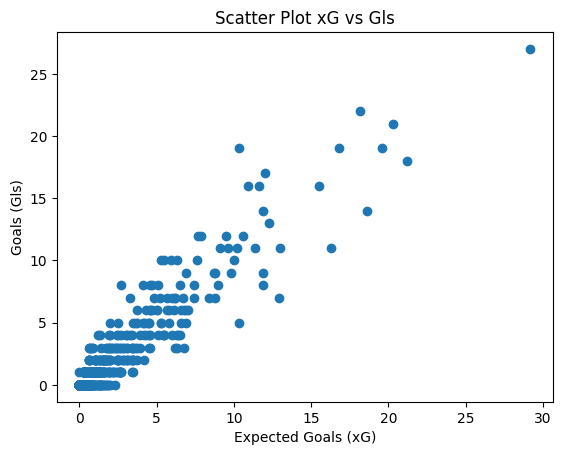

In [6]:
# =========================================
# 4. VISUALISASI AWAL
# =========================================
plt.figure()
plt.scatter(data["xG"], data["Gls"])
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals (Gls)")
plt.title("Scatter Plot xG vs Gls")
plt.show()

In [7]:
# =========================================
# 5. KORELASI
# =========================================
corr, p_corr = stats.pearsonr(data["xG"], data["Gls"])
print("\n=== KORELASI ===")
print("Korelasi Pearson:", round(corr,4))
print("p-value:", round(p_corr,6))


=== KORELASI ===
Korelasi Pearson: 0.9357
p-value: 0.0


In [8]:
# =========================================
# 6. REGRESI LINEAR
# =========================================
X = sm.add_constant(data["xG"])
y = data["Gls"]
model = sm.OLS(y, X).fit()

print("\n=== RINGKASAN MODEL REGRESI ===")
print(model.summary())


=== RINGKASAN MODEL REGRESI ===
                            OLS Regression Results                            
Dep. Variable:                    Gls   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.875
Method:                 Least Squares   F-statistic:                     4068.
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          9.38e-264
Time:                        14:31:45   Log-Likelihood:                -964.45
No. Observations:                 580   AIC:                             1933.
Df Residuals:                     578   BIC:                             1942.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.00

In [9]:
# =========================================
# 7. UJI HIPOTESIS
# =========================================
alpha = 0.05
p_value = model.pvalues["xG"]

print("\n=== UJI HIPOTESIS ===")
print("H0 : β1 = 0 (xG tidak berpengaruh terhadap Gls)")
print("H1 : β1 ≠ 0 (xG berpengaruh terhadap Gls)")
print("p-value:", p_value)

if p_value < alpha:
    print("Keputusan: Tolak H0")
else:
    print("Keputusan: Gagal Tolak H0")




=== UJI HIPOTESIS ===
H0 : β1 = 0 (xG tidak berpengaruh terhadap Gls)
H1 : β1 ≠ 0 (xG berpengaruh terhadap Gls)
p-value: 9.384416630084521e-264
Keputusan: Tolak H0



=== UJI ASUMSI REGRESI ===

1. Shapiro-Wilk
Statistik W = 0.8461
p-value = 0.0


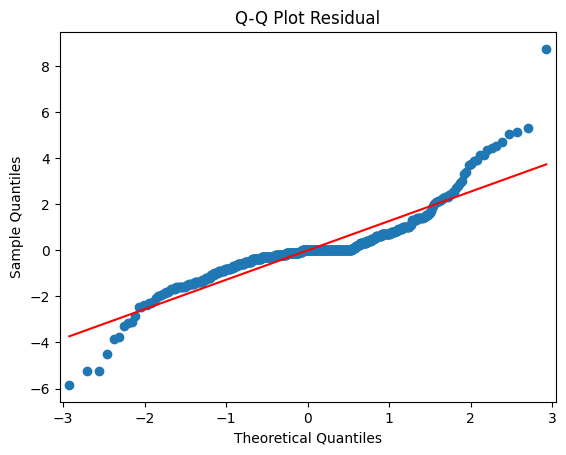


2. Breusch-Pagan
Statistik LM = 130.4291
p-value = 0.0


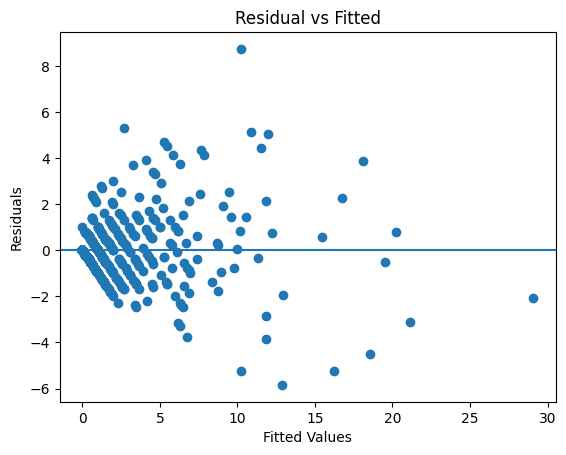


3. Durbin-Watson
Statistik DW = 2.0135


In [10]:
# =========================================
# 8. UJI ASUMSI REGRESI
# =========================================
print("\n=== UJI ASUMSI REGRESI ===")

# Normalitas Residual
shapiro = stats.shapiro(model.resid)
print("\n1. Shapiro-Wilk")
print("Statistik W =", round(shapiro.statistic,4))
print("p-value =", round(shapiro.pvalue,6))

# Q-Q Plot
sm.qqplot(model.resid, line='s')
plt.title("Q-Q Plot Residual")
plt.show()

# Homoskedastisitas
bp = het_breuschpagan(model.resid, model.model.exog)
print("\n2. Breusch-Pagan")
print("Statistik LM =", round(bp[0],4))
print("p-value =", round(bp[1],6))

# Plot Residual vs Fitted
plt.figure()
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted")
plt.show()

# Autokorelasi
dw = durbin_watson(model.resid)
print("\n3. Durbin-Watson")
print("Statistik DW =", round(dw,4))


In [11]:
# =========================================
# 9. INTERPRETASI KOEFISIEN
# =========================================
intercept = model.params["const"]
slope = model.params["xG"]

print("\n=== PERSAMAAN REGRESI ===")
print("Gls =", round(intercept,4), "+", round(slope,6), "* xG")




=== PERSAMAAN REGRESI ===
Gls = -0.0038 + 0.995952 * xG


In [ ]:
# =========================================
# 10. INTERVAL KEPERCAYAAN
# =========================================
print("\n=== INTERVAL KEPERCAYAAN 95% ===")
print(model.conf_int())



In [ ]:
# =========================================
# 11. KOEFISIEN DETERMINASI
# =========================================
r2 = model.rsquared
print("\n=== KOEFISIEN DETERMINASI ===")
print("R² =", round(r2,4))
print("Artinya", round(r2*100,2),
      "% variasi jumlah gol dijelaskan oleh xG.")


In [ ]:
# =========================================
# 12. VISUALISASI GARIS REGRESI
# =========================================
plt.figure()
plt.scatter(data["xG"], data["Gls"])

x_vals = np.linspace(data["xG"].min(), data["xG"].max(), 100)
y_vals = intercept + slope * x_vals

plt.plot(x_vals, y_vals, color='red')
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Goals (Gls)")
plt.title("Garis Regresi Linear (Gls ~ xG)")
plt.show()